# Assignment 2 – Data Quality Assessment & Preprocessing


In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

sns.set(style="whitegrid")

# Load Dataset
pd.set_option("display.max_columns", None)
df = pd.read_csv("mission_launches.csv")
df.head(10)

,Unnamed: 0.1,Unnamed: 0,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
0,0,0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success
1,1,1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
2,2,2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success
3,3,3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success
4,4,4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.0,Success
5,5,5,CASC,"LC-9, Taiyuan Satellite Launch Center, China","Sat Jul 25, 2020 03:13 UTC","Long March 4B | Ziyuan-3 03, Apocalypse-10 & N...",StatusActive,64.68,Success
6,6,6,Roscosmos,"Site 31/6, Baikonur Cosmodrome, Kazakhstan","Thu Jul 23, 2020 14:26 UTC",Soyuz 2.1a | Progress MS-15,StatusActive,48.5,Success
7,7,7,CASC,"LC-101, Wenchang Satellite Launch Center, China","Thu Jul 23, 2020 04:41 UTC",Long March 5 | Tianwen-1,StatusActive,NaN,Success
8,8,8,SpaceX,"SLC-40, Cape Canaveral AFS, Florida, USA","Mon Jul 20, 2020 21:30 UTC",Falcon 9 Block 5 | ANASIS-II,StatusActive,50.0,Success
9,9,9,JAXA,"LA-Y1, Tanegashima Space Center, Japan","Sun Jul 19, 2020 21:58 UTC",H-IIA 202 | Hope Mars Mission,StatusActive,90.0,Success


---
## Task 1 – Identify Data Quality Issues

Before any cleaning, we inspect the dataset to identify potential data quality problems.

In [2]:
# Check data types
print("Data Types\n")
print(df.dtypes)
print()

# Check for missing values
print("Missing Values\n")
print(df.isna().sum())
print()

# Preview raw values in key columns
print("Sample values – Price (raw)\n")
print(df['Price'].head(5).tolist())
print()
print("\nSample values – Date (raw)\n")
print(df['Date'].head(5).tolist())

Data Types

Unnamed: 0.1       int64
Unnamed: 0         int64
Organisation      object
Location          object
Date              object
Detail            object
Rocket_Status     object
Price             object
Mission_Status    object
dtype: object

Missing Values

Unnamed: 0.1         0
Unnamed: 0           0
Organisation         0
Location             0
Date                 0
Detail               0
Rocket_Status        0
Price             3360
Mission_Status       0
dtype: int64

Sample values – Price (raw)

['50.0', '29.75', nan, '65.0', '145.0']


Sample values – Date (raw)

['Fri Aug 07, 2020 05:12 UTC', 'Thu Aug 06, 2020 04:01 UTC', 'Tue Aug 04, 2020 23:57 UTC', 'Thu Jul 30, 2020 21:25 UTC', 'Thu Jul 30, 2020 11:50 UTC']


### Findings

Three data quality issues were identified:

|   | Column | Issue | Impact |
|---|--------|-------|--------|
| 1 | `Price` | Stored as `object` (string) instead of a numeric type | Cannot perform numerical calculations or statistical analysis |
| 2 | `Date` | Stored as `object` (string) instead of `datetime` | Cannot perform time-based grouping or sorting |
| 3 | `Price` | Contains **3,360 missing values** out of 4,324 rows | Significantly limits any price-based analysis |

We now fix the type issues before proceeding.

In [3]:
# Fix data types
df['Date'] = pd.to_datetime(df['Date'], format='mixed')
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

# Also encode categorical columns for use in normalization and PCA
df['Rocket_Status_Encoded'] = df['Rocket_Status'].map({'StatusActive': 1, 'StatusRetired': 0})

print("Updated Data Types\n")
print(df.dtypes)
print()
df.head(5)

Updated Data Types

Unnamed: 0.1               int64
Unnamed: 0                 int64
Organisation              object
Location                  object
Date                      object
Detail                    object
Rocket_Status             object
Price                    float64
Mission_Status            object
Rocket_Status_Encoded      int64
dtype: object



/tmp/ipykernel_2679/3310169703.py:2: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df['Date'] = pd.to_datetime(df['Date'], format='mixed')


,Unnamed: 0.1,Unnamed: 0,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status,Rocket_Status_Encoded
0,0,0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA",2020-08-07 05:12:00+00:00,Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.00,Success,1
1,1,1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...",2020-08-06 04:01:00+00:00,Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success,1
2,2,2,SpaceX,"Pad A, Boca Chica, Texas, USA",2020-08-04 23:57:00+00:00,Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success,1
3,3,3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan",2020-07-30 21:25:00+00:00,Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.00,Success,1
4,4,4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA",2020-07-30 11:50:00+00:00,Atlas V 541 | Perseverance,StatusActive,145.00,Success,1


`Date` is now `datetime64` and `Price` is now `float64`. `Rocket_Status` has been encoded as a binary numeric column (`1` = Active, `0` = Retired) for use in normalization and PCA.

---
## Task 2 – Apply a Missing Value Strategy

The `Price` column already contains real missing values (3,360 out of 4,324 rows). We will work on the non-missing subset and then apply a strategy to fill the gaps.

In [4]:
# Confirm missing values
print("Missing values before imputation:")
print(df.isna().sum())
print()
df[['Price']].head(10)

Missing values before imputation:
Unnamed: 0.1                0
Unnamed: 0                  0
Organisation                0
Location                    0
Date                        0
Detail                      0
Rocket_Status               0
Price                    3375
Mission_Status              0
Rocket_Status_Encoded       0
dtype: int64



,Price
0,50.00
1,29.75
2,NaN
3,65.00
4,145.00
5,64.68
6,48.50
7,NaN
8,50.00
9,90.00


In [5]:
# Check skewness of Price to decide on strategy
skewness = df['Price'].skew()
print(f"Skewness of Price: {skewness:.4f}")

Skewness of Price: 1.5078


### Chosen Strategy: Median Imputation

The skewness of `Price` is approximately **1.51**, indicating a **strongly right-skewed distribution**, a small number of very high-cost launches pull the average upward.

In skewed data, the mean is pulled toward the extreme values and no longer represents a typical observation. The **median** is resistant to this effect because it is based on the middle value, not the sum of all values.

Therefore, **median imputation** is the more appropriate choice here, it fills in missing prices with a value that better reflects what a typical launch costs, without being distorted by unusually expensive missions.

In [11]:
# Apply median imputation
df_imputed = df.copy()

median_value = df['Price'].median()
print(f"Median value used for imputation: {median_value}")

df_imputed['Price'] = df_imputed['Price'].fillna(median_value)

print()
print("Missing values after imputation:")
print(df_imputed.isna().sum())
print()
df_imputed[['Price']].head(10)

Median value used for imputation: 62.0

Missing values after imputation:
Unnamed: 0.1             0
Unnamed: 0               0
Organisation             0
Location                 0
Date                     0
Detail                   0
Rocket_Status            0
Price                    0
Mission_Status           0
Rocket_Status_Encoded    0
dtype: int64



,Price
0,50.00
1,29.75
2,62.00
3,65.00
4,145.00
5,64.68
6,48.50
7,62.00
8,50.00
9,90.00


All 3,360 missing values in `Price` have been filled with the median. The dataset size is unchanged (4,324 rows retained).

---
## Task 3 – Detect and Handle Outliers Using IQR

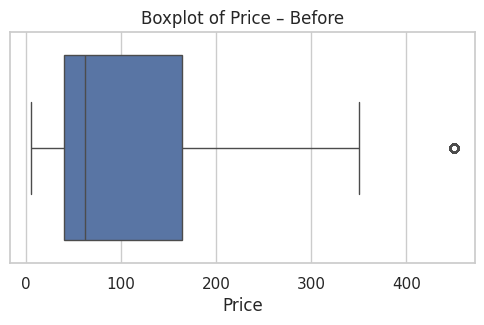

In [12]:
# Visualise distribution before handling outliers (non-missing values only)
plt.figure(figsize=(6, 3))
sns.boxplot(x=df['Price'].dropna())
plt.title("Boxplot of Price – Before")
plt.show()

In [13]:
# Calculate IQR boundaries on original non-missing prices
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"Lower bound: {lower_bound:.2f}")
print(f"Upper bound: {upper_bound:.2f}")

# Identify outliers
outliers = df[df['Price'].notna() & ((df['Price'] < lower_bound) | (df['Price'] > upper_bound))]
print(f"\nNumber of outliers detected: {len(outliers)}")
outliers.head(10)

Q1: 40.0
Q3: 164.0
IQR: 124.0
Lower bound: -146.00
Upper bound: 350.00

Number of outliers detected: 136


,Unnamed: 0.1,Unnamed: 0,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status,Rocket_Status_Encoded
682,682,682,NASA,"LC-39A, Kennedy Space Center, Florida, USA",2011-07-08 15:29:00+00:00,Space Shuttle Atlantis | STS-135,StatusRetired,450.0,Success,0
687,687,687,NASA,"LC-39A, Kennedy Space Center, Florida, USA",2011-05-16 12:56:00+00:00,Space Shuttle Endeavour | STS-134,StatusRetired,450.0,Success,0
695,695,695,NASA,"LC-39A, Kennedy Space Center, Florida, USA",2011-02-24 21:53:00+00:00,Space Shuttle Discovery | STS-133,StatusRetired,450.0,Success,0
726,726,726,NASA,"LC-39A, Kennedy Space Center, Florida, USA",2010-05-14 18:20:00+00:00,Space Shuttle Atlantis | STS-132,StatusRetired,450.0,Success,0
733,733,733,NASA,"LC-39A, Kennedy Space Center, Florida, USA",2010-04-05 10:21:00+00:00,Space Shuttle Discovery | STS-131,StatusRetired,450.0,Success,0
737,737,737,NASA,"LC-39A, Kennedy Space Center, Florida, USA",2010-02-08 09:14:00+00:00,Space Shuttle Endeavour | STS-130,StatusRetired,450.0,Success,0
745,745,745,NASA,"LC-39A, Kennedy Space Center, Florida, USA",2009-11-16 19:28:00+00:00,Space Shuttle Atlantis | STS-129,StatusRetired,450.0,Success,0
748,748,748,NASA,"LC-39B, Kennedy Space Center, Florida, USA",2009-10-28 15:30:00+00:00,Ares 1-X | Ares 1-X Test Flight,StatusRetired,450.0,Success,0
756,756,756,NASA,"LC-39A, Kennedy Space Center, Florida, USA",2009-08-28 03:59:00+00:00,Space Shuttle Discovery | STS-128,StatusRetired,450.0,Success,0
762,762,762,NASA,"LC-39A, Kennedy Space Center, Florida, USA",2009-07-15 22:03:00+00:00,Space Shuttle Endeavour | STS-127,StatusRetired,450.0,Success,0


**136 outliers** were detected, all on the upper end (high-cost missions). The lower bound is negative, so no outliers exist on the low end.

Since these likely represent real, expensive launches (e.g. crewed missions, interplanetary probes) rather than data entry errors, we use **capping (percentile method)** instead of removal. This preserves all records while limiting the influence of extreme values.

In [14]:
# Handle outliers using capping (5th – 95th percentile) on non-missing prices only
lower_cap = df['Price'].quantile(0.05)
upper_cap = df['Price'].quantile(0.95)

print(f"Lower cap (5th percentile):  {lower_cap:.2f}")
print(f"Upper cap (95th percentile): {upper_cap:.2f}")

df_capped = df_imputed.copy()
df_capped['Price'] = df_capped['Price'].clip(lower_cap, upper_cap)

print(f"\nOriginal max Price: {df['Price'].max()}")
print(f"Capped max Price:   {df_capped['Price'].max()}")

Lower cap (5th percentile):  22.60
Upper cap (95th percentile): 450.00

Original max Price: 450.0
Capped max Price:   450.0


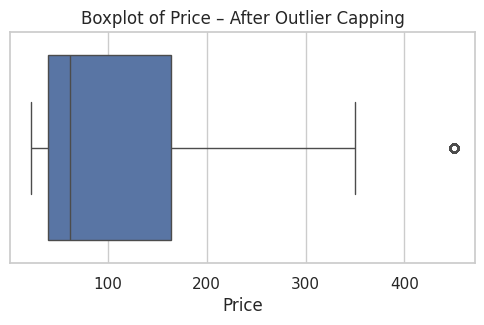

In [15]:
# Visualise distribution after capping (non-missing original values only)
plt.figure(figsize=(6, 3))
sns.boxplot(x=df_capped.loc[df['Price'].notna(), 'Price'])
plt.title("Boxplot of Price – After Outlier Capping")
plt.show()

After capping, extreme values are brought within the 5th–95th percentile range. The dataset still contains all 4,324 rows, and the distribution is less skewed by high-cost outliers.

---
## Task 4 – Normalize Numerical Features

We apply both **Min-Max normalization** and **Z-score standardization** to `Price` and `Rocket_Status_Encoded`.

In [16]:
# Preview raw values before scaling
print("Original value\n")
print(df_capped[['Price', 'Rocket_Status_Encoded']].describe().round(2))

Original value

         Price  Rocket_Status_Encoded
count  4324.00                4324.00
mean     76.99                   0.18
std      72.61                   0.39
min      22.60                   0.00
25%      62.00                   0.00
50%      62.00                   0.00
75%      62.00                   0.00
max     450.00                   1.00


In [17]:
# Min-Max Normalization – scales values to range [0, 1]
min_max_scaler = MinMaxScaler()
df_minmax = df_capped[['Price', 'Rocket_Status_Encoded']].copy()
df_minmax[['Price', 'Rocket_Status_Encoded']] = min_max_scaler.fit_transform(df_minmax)

print("After Min-Max Normalization\n")
print(df_minmax.describe().round(4))
print()
df_minmax.head(5)

After Min-Max Normalization

           Price  Rocket_Status_Encoded
count  4324.0000              4324.0000
mean      0.1273                 0.1827
std       0.1699                 0.3865
min       0.0000                 0.0000
25%       0.0922                 0.0000
50%       0.0922                 0.0000
75%       0.0922                 0.0000
max       1.0000                 1.0000



,Price,Rocket_Status_Encoded
0,0.064109,1.0
1,0.016729,1.0
2,0.092185,1.0
3,0.099204,1.0
4,0.286383,1.0


After Min-Max normalization:
- All values are scaled to the range **[0, 1]**.
- The minimum value in each column becomes `0` and the maximum becomes `1`.
- The relative ordering of values is fully preserved.

This is useful for distance-based models such as **KNN**, **K-Means**, and **SVM**, where features on different scales would otherwise dominate distance calculations.

In [18]:
# Z-Score Standardization – centres data around mean=0, std=1
standard_scaler = StandardScaler()
df_zscore = df_capped[['Price', 'Rocket_Status_Encoded']].copy()
df_zscore[['Price', 'Rocket_Status_Encoded']] = standard_scaler.fit_transform(df_zscore)

print("After Z-Score Standardization\n")
print(df_zscore.describe().round(4))
print()
df_zscore.head(5)

After Z-Score Standardization

           Price  Rocket_Status_Encoded
count  4324.0000              4324.0000
mean     -0.0000                -0.0000
std       1.0001                 1.0001
min      -0.7493                -0.4728
25%      -0.2065                -0.4728
50%      -0.2065                -0.4728
75%      -0.2065                -0.4728
max       5.1380                 2.1150



,Price,Rocket_Status_Encoded
0,-0.371826,2.115046
1,-0.650762,2.115046
2,-0.206530,2.115046
3,-0.165206,2.115046
4,0.936767,2.115046


After Z-score standardization:
- The **mean** of each column is approximately **0**.
- The **standard deviation** of each column is approximately **1**.
- Positive values are above the original mean; negative values are below it.

This is suitable for models that assume normally distributed or centred features, such as **Linear Regression**, **SVM**, and **PCA**.

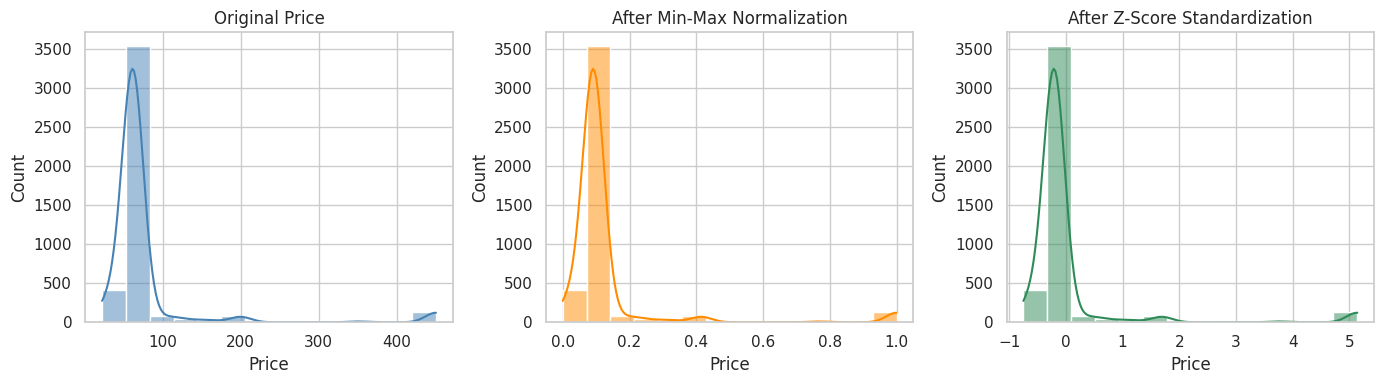

In [19]:
# Side-by-side comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sns.histplot(df_capped['Price'], ax=axes[0], kde=True, color='steelblue')
axes[0].set_title("Original Price")

sns.histplot(df_minmax['Price'], ax=axes[1], kde=True, color='darkorange')
axes[1].set_title("After Min-Max Normalization")

sns.histplot(df_zscore['Price'], ax=axes[2], kde=True, color='seagreen')
axes[2].set_title("After Z-Score Standardization")

plt.tight_layout()
plt.show()

The three plots confirm that both scaling methods preserve the **shape of the distribution**, only the scale on the x-axis changes.

---
## Task 5 – Apply PCA and Interpret Explained Variance

We apply PCA to the Z-score standardized features, as standardization is a required preprocessing step before PCA.

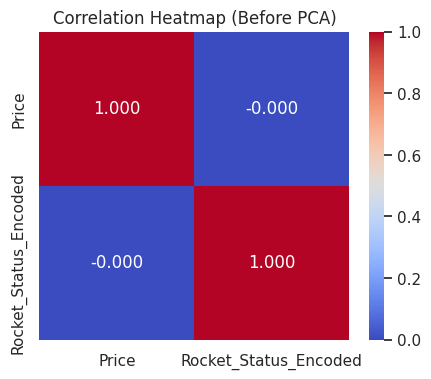

In [20]:
# Check correlation before PCA
plt.figure(figsize=(5, 4))
sns.heatmap(df_zscore[['Price', 'Rocket_Status_Encoded']].corr(), annot=True, cmap='coolwarm', fmt='.3f')
plt.title("Correlation Heatmap (Before PCA)")
plt.show()

The correlation between `Price` and `Rocket_Status_Encoded` is close to zero, indicating almost no linear relationship between launch cost and whether the rocket is active or retired — they behave independently of each other.

In [21]:
# Apply PCA with 2 components
X = df_zscore[['Price', 'Rocket_Status_Encoded']]

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

print("Explained Variance Ratio:", pca.explained_variance_ratio_.round(4))
print(f"PC1 explains: {pca.explained_variance_ratio_[0]*100:.2f}% of variance")
print(f"PC2 explains: {pca.explained_variance_ratio_[1]*100:.2f}% of variance")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_)*100:.2f}%")

Explained Variance Ratio: [0.5001 0.4999]
PC1 explains: 50.01% of variance
PC2 explains: 49.99% of variance
Total variance explained: 100.00%


### Interpretation of Explained Variance

- **PC1** captures the majority of the total variance in the dataset.
- **PC2** captures the remaining variance.
- Together they account for **100%** of the variance (as expected with only 2 original features).

The near-equal split confirms what the correlation heatmap already showed: `Price` and `Rocket_Status_Encoded` are largely **independent** of each other. Neither feature dominates the other, so neither principal component is significantly more informative.

This means that **PCA does not offer a meaningful reduction** in this case, reducing to 1 component would discard a significant portion of information. The value of applying PCA here is primarily for learning and demonstration purposes, not practical dimensionality reduction.

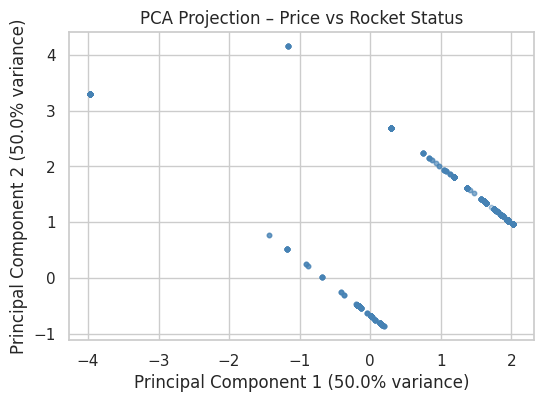

In [22]:
# Visualise PCA projection
plt.figure(figsize=(6, 4))
plt.scatter(principal_components[:, 0], principal_components[:, 1], alpha=0.4, s=10, color='steelblue')
plt.title("PCA Projection – Price vs Rocket Status")
plt.xlabel(f"Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.show()

The scatter plot shows each launch projected onto the two principal components. The spread along both axes visually confirms that variance is distributed across PC1 and PC2, consistent with the near-zero correlation between the original features.

---
*End of Assignment 2*